In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import zipfile
import os

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown


# =========================
# CONFIGURAZIONE PATH PROGETTO
# =========================

PROJECT_NAME = "MammoDiffusion"

# Lascia None se esegui il notebook dalla repo o dalla cartella notebooks/.
# Su Colab/Drive puoi impostare ad esempio:
# PROJECT_ROOT_OVERRIDE = "/content/drive/MyDrive/MammoDiffusion"
PROJECT_ROOT_OVERRIDE = None


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    """Trova automaticamente la root del progetto MammoDiffusion."""
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE non esiste: {root}")
        return root

    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name:
            return candidate
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    for candidate in [
        cwd / project_name,
        Path("/content") / project_name,
        Path("/content/drive/MyDrive") / project_name,
        Path.home() / project_name,
        Path.home() / "Progetto" / project_name,
    ]:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Non riesco a trovare la root del progetto MammoDiffusion.\n"
        "Esegui il notebook dalla repo clonata oppure imposta PROJECT_ROOT_OVERRIDE."
    )


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "data"
DATA_ORIGINAL_DIR = DATA_DIR / "original"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
ARCHIVES_DIR = DATA_DIR / "archives"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_DIR = PROJECT_ROOT / "results"

for directory in [DATA_ORIGINAL_DIR, DATA_PROCESSED_DIR, EXPERIMENTS_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


# DATASET PREPROCESSATO

# Il file Drive si chiama processed.zip e deve contenere direttamente:
# train/0/, train/1/, val/0/, val/1/, test/0/, test/1/ e metadata/*.csv.
# Dopo l'estrazione il risultato atteso è:
# MammoDiffusion/data/processed/train/0/*.png
# MammoDiffusion/data/processed/train/1/*.png
# MammoDiffusion/data/processed/val/0/*.png
# MammoDiffusion/data/processed/val/1/*.png
# MammoDiffusion/data/processed/test/0/*.png
# MammoDiffusion/data/processed/test/1/*.png
# MammoDiffusion/data/processed/metadata/*.csv
PROCESSED_DRIVE_ID = "16qdV3arYBeMK7nLZpm3dwGV4lzTLVYmo"
PROCESSED_ZIP_PATH = ARCHIVES_DIR / "processed.zip"
PROCESSED_DIR = DATA_PROCESSED_DIR

# True = riscarica processed.zip e riestrae tutto, cancellando data/processed/.
# False = se train/val/test con sottocartelle 0/1 sono già presenti, non scarica nulla.
FORCE_REDOWNLOAD = False

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("PROCESSED_ZIP_PATH:", PROCESSED_ZIP_PATH)

PROJECT_ROOT: /home/fede/Documenti/MammoDiffusion
PROCESSED_DIR: /home/fede/Documenti/MammoDiffusion/data/processed
PROCESSED_ZIP_PATH: /home/fede/Documenti/MammoDiffusion/data/archives/processed.zip


In [2]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
EXPECTED_SPLITS = ["train", "val", "test"]
EXPECTED_LABELS = ["0", "1"]
REQUIRED_METADATA = ["all_processed.csv", "train.csv", "val.csv", "test.csv"]


def count_images(folder):
    """Conta le immagini dentro una cartella, includendo eventuali sottocartelle."""
    folder = Path(folder)
    if not folder.is_dir():
        return 0

    return sum(
        1
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def get_split_label_counts(processed_dir):
    """Conta immagini in data/processed/<split>/<label>/, quindi train/0, train/1, ecc."""
    processed_dir = Path(processed_dir).resolve()

    rows = []
    for split in EXPECTED_SPLITS:
        for label in EXPECTED_LABELS:
            rows.append({
                "split": split,
                "label": int(label),
                "folder": str(processed_dir / split / label),
                "n_images": count_images(processed_dir / split / label),
            })

    return pd.DataFrame(rows)


def processed_dataset_ready(processed_dir):
    """
    True se data/processed contiene la struttura corretta:
        train/0, train/1, val/0, val/1, test/0, test/1
    e ciascuna cartella contiene almeno una immagine.
    """
    processed_dir = Path(processed_dir).resolve()
    if not processed_dir.exists():
        return False

    counts_df = get_split_label_counts(processed_dir)
    ready = (counts_df["n_images"] > 0).all()

    if not ready and any((processed_dir / split).exists() for split in EXPECTED_SPLITS):
        print("Dataset preprocessato trovato, ma struttura incompleta:")
        print(counts_df[["split", "label", "n_images"]].to_string(index=False))

    return bool(ready)


def metadata_complete(processed_dir):
    """True se data/processed/metadata contiene tutti i CSV attesi."""
    metadata_dir = Path(processed_dir) / "metadata"
    return all((metadata_dir / name).exists() for name in REQUIRED_METADATA)


def parse_filename_metadata(image_path):
    """
    Ricava i metadata minimi dal nome file creato dal preprocessing:
    patient_id_image_id_laterality_view.png
    """
    parts = Path(image_path).stem.split("_")

    patient_id = parts[0] if len(parts) >= 1 else Path(image_path).stem
    image_id = parts[1] if len(parts) >= 2 else Path(image_path).stem
    laterality = parts[2] if len(parts) >= 3 else "unknown"
    view = parts[3] if len(parts) >= 4 else "unknown"

    return patient_id, image_id, laterality, view


def rebuild_metadata_from_folders(processed_dir):
    """Ricostruisce i CSV metadata se mancano, usando train/val/test/0-1/file.png."""
    processed_dir = Path(processed_dir).resolve()
    metadata_dir = processed_dir / "metadata"
    metadata_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    for split in EXPECTED_SPLITS:
        for label_name in EXPECTED_LABELS:
            label_dir = processed_dir / split / label_name
            label = int(label_name)

            for image_path in sorted(label_dir.rglob("*")):
                if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                    continue

                patient_id, image_id, laterality, view = parse_filename_metadata(image_path)

                rows.append({
                    "patient_id": str(patient_id),
                    "image_id": str(image_id),
                    "laterality": str(laterality),
                    "view": str(view),
                    "label": label,
                    "cancer": label,
                    "patient_label": label,
                    "split": split,
                    "source": "real",
                    "original_path": "",
                    "processed_path": str(image_path),
                })

    if not rows:
        raise FileNotFoundError(f"Nessuna immagine valida trovata in {processed_dir}")

    df = pd.DataFrame(rows).sort_values(
        ["split", "label", "patient_id", "image_id"]
    ).reset_index(drop=True)

    df.to_csv(metadata_dir / "all_processed.csv", index=False)

    for split in EXPECTED_SPLITS:
        df[df["split"] == split].reset_index(drop=True).to_csv(
            metadata_dir / f"{split}.csv",
            index=False,
        )

    print("Metadata CSV ricostruiti in:", metadata_dir)
    print(pd.crosstab(df["split"], df["label"]))


def ensure_metadata(processed_dir):
    if metadata_complete(processed_dir):
        print("Metadata CSV già presenti:", Path(processed_dir) / "metadata")
        return

    print("Metadata CSV mancanti o incompleti: li ricostruisco da train/val/test/0-1.")
    rebuild_metadata_from_folders(processed_dir)


def download_processed_zip():
    if PROCESSED_ZIP_PATH.exists() and not FORCE_REDOWNLOAD:
        if zipfile.is_zipfile(PROCESSED_ZIP_PATH):
            print("Archivio già presente, salto download:", PROCESSED_ZIP_PATH)
            return
        print("Archivio presente ma non valido: lo riscarico.")
        PROCESSED_ZIP_PATH.unlink()

    elif PROCESSED_ZIP_PATH.exists():
        PROCESSED_ZIP_PATH.unlink()

    print("Download di processed.zip da Google Drive...")
    gdown.download(
        id=PROCESSED_DRIVE_ID,
        output=str(PROCESSED_ZIP_PATH),
        quiet=False,
    )

    if not PROCESSED_ZIP_PATH.exists() or PROCESSED_ZIP_PATH.stat().st_size == 0:
        raise RuntimeError(
            "Download fallito. Controlla che il file Drive sia condiviso con "
            "'Chiunque abbia il link'."
        )

    if not zipfile.is_zipfile(PROCESSED_ZIP_PATH):
        raise RuntimeError(f"Il file scaricato non sembra uno ZIP valido: {PROCESSED_ZIP_PATH}")

    print("Download completato:", PROCESSED_ZIP_PATH)


def clear_processed_dir():
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

    for item in PROCESSED_DIR.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()


def extract_processed_zip():
    print("Estrazione di processed.zip dentro:", PROCESSED_DIR)
    clear_processed_dir()

    with zipfile.ZipFile(PROCESSED_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(PROCESSED_DIR)


def prepare_processed_dataset():
    """
    Usa data/processed se è già pronta.
    Altrimenti scarica processed.zip e lo estrae direttamente in data/processed/.
    """
    if processed_dataset_ready(PROCESSED_DIR) and not FORCE_REDOWNLOAD:
        print("Dataset preprocessato già presente: salto download ed estrazione.")
        ensure_metadata(PROCESSED_DIR)
        return PROCESSED_DIR.resolve()
    
    PROCESSED_ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    
    download_processed_zip()
    extract_processed_zip()

    if not processed_dataset_ready(PROCESSED_DIR):
        counts_df = get_split_label_counts(PROCESSED_DIR)
        print(counts_df[["split", "label", "folder", "n_images"]].to_string(index=False))
        raise FileNotFoundError(
            "processed.zip è stato estratto, ma la struttura non è quella attesa.\n"
            "Lo ZIP deve contenere direttamente train/0, train/1, val/0, val/1, "
            "test/0, test/1 e metadata/*.csv."
        )

    ensure_metadata(PROCESSED_DIR)

    print("Dataset preprocessato pronto.")
    print("DATASET_ROOT:", PROCESSED_DIR.resolve())
    print("\nConteggio immagini:")
    print(get_split_label_counts(PROCESSED_DIR)[["split", "label", "n_images"]].to_string(index=False))

    return PROCESSED_DIR.resolve()


DATASET_ROOT = prepare_processed_dataset()

METADATA_DIR = DATASET_ROOT / "metadata"
ALL_CSV_PATH = METADATA_DIR / "all_processed.csv"
TRAIN_CSV_PATH = METADATA_DIR / "train.csv"
VAL_CSV_PATH = METADATA_DIR / "val.csv"
TEST_CSV_PATH = METADATA_DIR / "test.csv"

print("\nCSV metadata:")
print("ALL_CSV_PATH:", ALL_CSV_PATH)
print("TRAIN_CSV_PATH:", TRAIN_CSV_PATH)
print("VAL_CSV_PATH:", VAL_CSV_PATH)
print("TEST_CSV_PATH:", TEST_CSV_PATH)

Dataset preprocessato già presente: salto download ed estrazione.
Metadata CSV già presenti: /home/fede/Documenti/MammoDiffusion/data/processed/metadata

CSV metadata:
ALL_CSV_PATH: /home/fede/Documenti/MammoDiffusion/data/processed/metadata/all_processed.csv
TRAIN_CSV_PATH: /home/fede/Documenti/MammoDiffusion/data/processed/metadata/train.csv
VAL_CSV_PATH: /home/fede/Documenti/MammoDiffusion/data/processed/metadata/val.csv
TEST_CSV_PATH: /home/fede/Documenti/MammoDiffusion/data/processed/metadata/test.csv


In [3]:
def load_metadata(csv_path, dataset_root):
    df = pd.read_csv(csv_path).copy()

    required_cols = ["patient_id", "image_id", "label", "split", "processed_path"]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Mancano colonne obbligatorie in {csv_path}: {missing_cols}")

    df["patient_id"] = df["patient_id"].astype(str)
    df["image_id"] = df["image_id"].astype(str)
    df["label"] = df["label"].astype(int)
    df["split"] = df["split"].astype(str)

    # I vecchi processed_path sono stati creati su Windows.
    # Su Ubuntu Path(...).name non separa correttamente i backslash.
    # Quindi normalizziamo prima i separatori.
    df["filename"] = df["processed_path"].apply(
        lambda p: str(p).replace("\\", "/").split("/")[-1]
    )

    # Ricostruiamo il path locale corretto usando la struttura reale dell'archivio
    df["processed_path"] = df.apply(
        lambda row: str(
            dataset_root / row["split"] / str(row["label"]) / row["filename"]
        ),
        axis=1
    )

    df["file_exists"] = df["processed_path"].apply(lambda p: Path(p).exists())

    missing_files = df[~df["file_exists"]]

    if len(missing_files) > 0:
        print(f"Attenzione: {len(missing_files)} immagini non trovate.")
        display(missing_files[["patient_id", "image_id", "split", "label", "filename", "processed_path"]].head(10))

        print("\nEsempi di path ricostruiti non trovati:")
        for p in missing_files["processed_path"].head(10):
            print(p)

        raise FileNotFoundError("Alcune immagini preprocessate non sono state trovate.")

    df = df.drop(columns=["file_exists"])

    return df

In [4]:
processed_df = load_metadata(ALL_CSV_PATH, DATASET_ROOT)
train_df = load_metadata(TRAIN_CSV_PATH, DATASET_ROOT)
val_df = load_metadata(VAL_CSV_PATH, DATASET_ROOT)
test_df = load_metadata(TEST_CSV_PATH, DATASET_ROOT)

print("Dataset caricato correttamente.")
print("Totale:", len(processed_df))
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nDistribuzione split/label:")
print(pd.crosstab(processed_df["split"], processed_df["label"]))

display(processed_df.head())

Dataset caricato correttamente.
Totale: 2916
Train: 2041
Val: 437
Test: 438

Distribuzione split/label:
label     0    1
split           
test    365   73
train  1701  340
val     364   73


,patient_id,image_id,laterality,view,label,cancer,patient_label,split,source,original_path,processed_path,visual_side_before,visual_side_after,left_ratio_before,right_ratio_before,flipped_by_visual_rule,normalized_tissue_side,normalized_laterality,filename
0,8248,1228024526,L,MLO,1,1,1,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,/home/fede/Documenti/MammoDiffusion/data/proce...,left,left,0.855382,0.144618,False,left,L,8248_1228024526_L_MLO.png
1,32984,1893902734,L,MLO,0,0,0,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,/home/fede/Documenti/MammoDiffusion/data/proce...,right,left,0.158146,0.841854,True,left,L,32984_1893902734_L_MLO.png
2,37629,1196209769,R,MLO,0,0,0,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,/home/fede/Documenti/MammoDiffusion/data/proce...,right,left,0.004466,0.995534,True,left,L,37629_1196209769_R_MLO.png
3,54728,189177296,R,MLO,0,0,0,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,/home/fede/Documenti/MammoDiffusion/data/proce...,right,left,0.002680,0.997320,True,left,L,54728_189177296_R_MLO.png
4,31287,1630385647,L,MLO,0,0,0,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,/home/fede/Documenti/MammoDiffusion/data/proce...,left,left,0.799693,0.200307,False,left,L,31287_1630385647_L_MLO.png


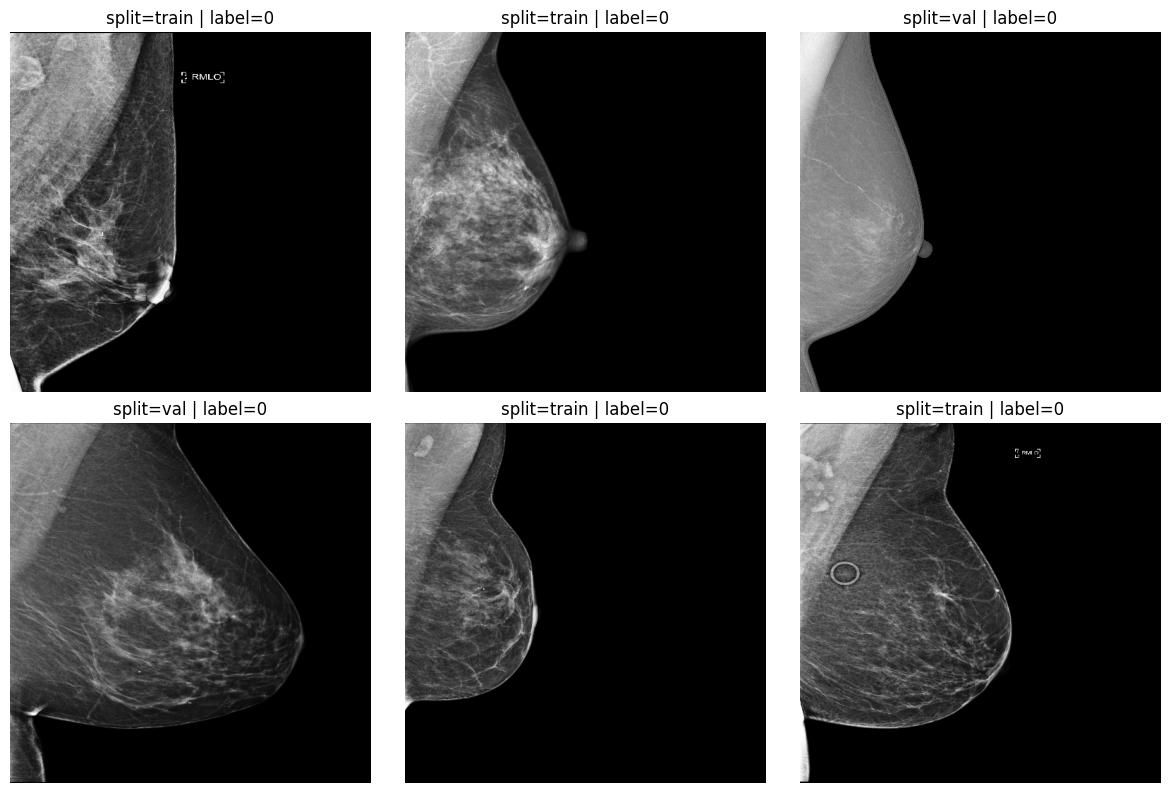

26660_960889337_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
65493_880741065_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
2671_657202909_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: val
62351_183239079_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: val
61080_1474548138_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
55043_1224521855_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train


In [5]:
sample_df = processed_df.sample(min(6, len(processed_df)), random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img = Image.open(row["processed_path"]).convert("L")

    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(f'split={row["split"]} | label={row["label"]}')
    plt.axis("off")

plt.tight_layout()
plt.show()

for _, row in sample_df.iterrows():
    img = Image.open(row["processed_path"])
    print(
        Path(row["processed_path"]).name,
        "| mode:", img.mode,
        "| size:", img.size,
        "| label:", row["label"],
        "| split:", row["split"]
    )

In [6]:
# Config fine-tuning StableDiffusion2.1

# Modello Stable Diffusion 2.1 scaricato da Drive.
# Zip contenente il modello Diffusers con model_index.json,
# unet/, vae/, text_encoder/, tokenizer/, scheduler/.
SD21_MODEL_DRIVE_ID = "10XRn-bxpp7tP6ROWLYpeCNYJZIaHfMUt"

FORCE_MODEL_REDOWNLOAD = False

# Cartelle di lavoro dentro la struttura MammoDiffusion.
EXPERIMENT_NAME = "20260607_sd21_rsna_mlo_512"
EXPERIMENT_DIR = EXPERIMENTS_DIR / EXPERIMENT_NAME

PRETRAINED_MODEL_DIR = EXPERIMENT_DIR / "pretrained_model" / "stable-diffusion-2-1-base"
PRETRAINED_MODEL_ZIP_PATH = EXPERIMENT_DIR / "archives" / "stable-diffusion-2-1-base.zip"
MODEL_EXTRACT_TMP_DIR = EXPERIMENT_DIR / "_model_extract_tmp"

SD_WORK_DIR = EXPERIMENT_DIR

SD_DATASET_DIR = EXPERIMENT_DIR / "sd21_rsna_conditioned"
SD_TRAIN_DIR = SD_DATASET_DIR / "train"

DIFFUSERS_REPO_DIR = EXPERIMENT_DIR / "diffusers_repo"
HF_CACHE_DIR = EXPERIMENT_DIR / "hf_cache"

SD_OUTPUT_DIR = EXPERIMENT_DIR / "model"
LOGS_DIR = EXPERIMENT_DIR / "logs"
GENERATED_SAMPLES_DIR = EXPERIMENT_DIR / "generated_samples"
CONFIG_PATH = EXPERIMENT_DIR / "config.json"

MODEL_WEIGHT_ALIASES = {
    "text_encoder": {
        "source": "model.fp16.safetensors",
        "target": "model.safetensors",
    },
    "unet": {
        "source": "diffusion_pytorch_model.fp16.safetensors",
        "target": "diffusion_pytorch_model.safetensors",
    },
    "vae": {
        "source": "diffusion_pytorch_model.fp16.safetensors",
        "target": "diffusion_pytorch_model.safetensors",
    },
}

for directory in [
    EXPERIMENT_DIR,
    SD_DATASET_DIR,
    SD_TRAIN_DIR,
    HF_CACHE_DIR,
    SD_OUTPUT_DIR,
    LOGS_DIR,
    GENERATED_SAMPLES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Prompt condizionati dalle label
POSITIVE_PROMPT = (
    "grayscale MLO mammogram, breast cancer positive, "
    "malignant finding, suspicious lesion, medical imaging"
)

NEGATIVE_PROMPT = (
    "grayscale MLO mammogram, breast cancer negative, "
    "no malignant finding, normal screening mammogram, medical imaging"
)

def label_to_prompt(label):
    label = int(label)

    if label == 1:
        return POSITIVE_PROMPT

    if label == 0:
        return NEGATIVE_PROMPT

    raise ValueError(f"Label non valida: {label}")


print("Modello locale:", PRETRAINED_MODEL_DIR)
print("Dataset preprocessato:", DATASET_ROOT)
print("Dataset training SD:", SD_TRAIN_DIR)
print("Output fine-tuning:", SD_OUTPUT_DIR)

Modello locale: /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/pretrained_model/stable-diffusion-2-1-base
Dataset preprocessato: /home/fede/Documenti/MammoDiffusion/data/processed
Dataset training SD: /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/sd21_rsna_conditioned/train
Output fine-tuning: /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/model


In [7]:
def local_sd_model_ready(model_dir):
    """
    Controlla se il modello Stable Diffusion 2.1 locale è già estratto
    e ha i nomi dei pesi compatibili con Diffusers.
    """
    model_dir = Path(model_dir)

    required_paths = [
        model_dir / "model_index.json",
        model_dir / "scheduler",
        model_dir / "tokenizer",
        model_dir / "text_encoder",
        model_dir / "vae",
        model_dir / "unet",
        model_dir / "text_encoder" / "model.safetensors",
        model_dir / "unet" / "diffusion_pytorch_model.safetensors",
        model_dir / "vae" / "diffusion_pytorch_model.safetensors",
    ]

    return all(path.exists() for path in required_paths)
    

def has_diffusers_structure(model_dir):
    """
    Controlla solo la struttura base del modello Diffusers.
    Non controlla ancora i nomi finali dei pesi.
    """
    model_dir = Path(model_dir)

    required_paths = [
        model_dir / "model_index.json",
        model_dir / "scheduler",
        model_dir / "tokenizer",
        model_dir / "text_encoder",
        model_dir / "vae",
        model_dir / "unet",
    ]

    return all(path.exists() for path in required_paths)
    

def find_diffusers_model_dir(root_dir):
    """
    Cerca dentro una cartella estratta il punto in cui si trova davvero model_index.json.
    Serve perché lo zip potrebbe contenere direttamente i file del modello
    oppure una cartella intermedia.
    """
    root_dir = Path(root_dir)

    candidates = [root_dir]
    candidates.extend(path.parent for path in root_dir.rglob("model_index.json"))

    for candidate in candidates:
        if has_diffusers_structure(candidate):
            return candidate

    return None


def download_pretrained_model_zip():
    if PRETRAINED_MODEL_ZIP_PATH.exists() and not FORCE_MODEL_REDOWNLOAD:
        if zipfile.is_zipfile(PRETRAINED_MODEL_ZIP_PATH):
            print("Archivio modello già presente, salto download:", PRETRAINED_MODEL_ZIP_PATH)
            return
        print("Archivio modello presente ma non valido: lo riscarico.")
        PRETRAINED_MODEL_ZIP_PATH.unlink()

    elif PRETRAINED_MODEL_ZIP_PATH.exists():
        PRETRAINED_MODEL_ZIP_PATH.unlink()

    PRETRAINED_MODEL_ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)

    print("Download del modello Stable Diffusion 2.1 da Google Drive...")
    gdown.download(
        id=SD21_MODEL_DRIVE_ID,
        output=str(PRETRAINED_MODEL_ZIP_PATH),
        quiet=False,
    )

    if not PRETRAINED_MODEL_ZIP_PATH.exists() or PRETRAINED_MODEL_ZIP_PATH.stat().st_size == 0:
        raise RuntimeError(
            "Download del modello fallito. Controlla che il file Drive sia condiviso con "
            "'Chiunque abbia il link'."
        )

    if not zipfile.is_zipfile(PRETRAINED_MODEL_ZIP_PATH):
        raise RuntimeError(f"Il file scaricato non sembra uno ZIP valido: {PRETRAINED_MODEL_ZIP_PATH}")

    print("Download modello completato:", PRETRAINED_MODEL_ZIP_PATH)


def extract_pretrained_model_zip():
    print("Estrazione del modello Stable Diffusion 2.1...")

    if MODEL_EXTRACT_TMP_DIR.exists():
        shutil.rmtree(MODEL_EXTRACT_TMP_DIR)

    MODEL_EXTRACT_TMP_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(PRETRAINED_MODEL_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(MODEL_EXTRACT_TMP_DIR)

    extracted_model_dir = find_diffusers_model_dir(MODEL_EXTRACT_TMP_DIR)

    if extracted_model_dir is None:
        raise FileNotFoundError(
            "Lo zip è stato estratto, ma non trovo una struttura Diffusers valida.\n"
            "Mi aspetto model_index.json e le cartelle scheduler/, tokenizer/, "
            "text_encoder/, vae/, unet/."
        )

    PRETRAINED_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)

    if PRETRAINED_MODEL_DIR.exists():
        shutil.rmtree(PRETRAINED_MODEL_DIR)

    shutil.copytree(extracted_model_dir, PRETRAINED_MODEL_DIR)

    create_model_weight_aliases(PRETRAINED_MODEL_DIR, MODEL_WEIGHT_ALIASES)
    
    shutil.rmtree(MODEL_EXTRACT_TMP_DIR)
    
    print("Modello estratto in:", PRETRAINED_MODEL_DIR)

def create_model_weight_aliases(model_dir, aliases):
    """
    Crea automaticamente i nomi standard attesi da Diffusers
    partendo dai file fp16 presenti nel modello scaricato.

    Esempio:
    unet/diffusion_pytorch_model.fp16.safetensors
    -> unet/diffusion_pytorch_model.safetensors

    È replicabile: non modifica Drive, agisce solo sulla copia locale estratta.
    """
    model_dir = Path(model_dir)

    for subfolder, names in aliases.items():
        source_path = model_dir / subfolder / names["source"]
        target_path = model_dir / subfolder / names["target"]

        if target_path.exists():
            print(f"Alias già presente: {target_path.relative_to(model_dir)}")
            continue

        if not source_path.exists():
            raise FileNotFoundError(
                f"Non trovo il file sorgente fp16:\n{source_path}\n"
                f"Controlla il contenuto dello zip del modello."
            )

        try:
            target_path.symlink_to(source_path.name)
            print(
                f"Creato symlink: {target_path.relative_to(model_dir)} "
                f"-> {source_path.name}"
            )
        except OSError:
            shutil.copy2(source_path, target_path)
            print(
                f"Creato alias tramite copia: {target_path.relative_to(model_dir)}"
            )

def prepare_pretrained_model():
    """
    Usa il modello locale se già presente.
    Altrimenti scarica lo zip da Drive e lo estrae dentro experiments/.
    """
    if local_sd_model_ready(PRETRAINED_MODEL_DIR) and not FORCE_MODEL_REDOWNLOAD:
        print("Modello Stable Diffusion 2.1 già presente: salto download ed estrazione.")
        return PRETRAINED_MODEL_DIR.resolve()

    download_pretrained_model_zip()
    extract_pretrained_model_zip()

    if not local_sd_model_ready(PRETRAINED_MODEL_DIR):
        raise FileNotFoundError(
            "Il modello è stato estratto, ma la struttura finale non è valida."
        )

    print("Modello Stable Diffusion 2.1 pronto.")
    return PRETRAINED_MODEL_DIR.resolve()


LOCAL_MODEL_DIR = prepare_pretrained_model()

print("LOCAL_MODEL_DIR:", LOCAL_MODEL_DIR)

Modello Stable Diffusion 2.1 già presente: salto download ed estrazione.
LOCAL_MODEL_DIR: /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/pretrained_model/stable-diffusion-2-1-base


In [8]:
# Creazione del dataset di training per il diffusore

# Quante copie augmentate creare per ogni immagine positiva.
# 0 = nessuna augmentation positiva.
# 1 = ogni positivo ha 1 copia augmentata.
# 2 = ogni positivo ha 2 copie augmentate, ecc.
POSITIVE_AUGMENT_COPIES = 2

# Se True, cancella e ricrea la cartella SD_TRAIN_DIR.
RESET_SD_DATASET = False

if RESET_SD_DATASET and SD_TRAIN_DIR.exists():
    shutil.rmtree(SD_TRAIN_DIR)

SD_TRAIN_DIR.mkdir(parents=True, exist_ok=True)

# Usiamo SOLO train_df, perché val/test devono restare reali e non contaminati.
sd_source_df = train_df.copy().reset_index(drop=True)

required_cols = ["patient_id", "image_id", "label", "split", "processed_path"]
missing_cols = [col for col in required_cols if col not in sd_source_df.columns]

if missing_cols:
    raise ValueError(f"Mancano colonne obbligatorie in train_df: {missing_cols}")

print("Distribuzione train originale:")
print(sd_source_df["label"].value_counts())


def mild_positive_augmentation(img, aug_idx):
    """
    Augmentation leggera per mammografie positive.
    Non fa flip, perché il preprocessing ha già normalizzato il tessuto verso sinistra.
    Applica solo piccole variazioni di contrasto/luminosità/rumore.
    """
    arr = np.array(img).astype(np.float32)

    rng = np.random.default_rng(42 + aug_idx)

    # Piccola variazione contrasto
    contrast = rng.uniform(0.90, 1.10)

    # Piccola variazione luminosità
    brightness = rng.uniform(-8, 8)

    # Rumore molto leggero
    noise = rng.normal(loc=0.0, scale=2.0, size=arr.shape)

    mean = arr.mean()
    arr = (arr - mean) * contrast + mean
    arr = arr + brightness + noise

    arr = np.clip(arr, 0, 255).astype(np.uint8)

    return Image.fromarray(arr, mode="L")


metadata_rows = []
out_idx = 0

for row_idx, row in sd_source_df.iterrows():
    label = int(row["label"])
    src_path = Path(row["processed_path"])

    if not src_path.exists():
        raise FileNotFoundError(f"Immagine non trovata: {src_path}")

    # Carico grayscale dal dataset preprocessato
    img_l = Image.open(src_path).convert("L")

    # Stable Diffusion vuole RGB, quindi duplico il grayscale su 3 canali
    img_rgb = img_l.convert("RGB")

    out_name = f"mammo_{out_idx:06d}_label{label}.png"
    out_path = SD_TRAIN_DIR / out_name
    img_rgb.save(out_path)

    metadata_rows.append({
        "file_name": out_name,
        "text": label_to_prompt(label),
        "label": label,
        "patient_id": str(row["patient_id"]),
        "image_id": str(row["image_id"]),
        "source": "real",
        "original_processed_path": str(src_path)
    })

    out_idx += 1

    # Augmentation SOLO per classe positiva
    if label == 1 and POSITIVE_AUGMENT_COPIES > 0:
        for aug_num in range(POSITIVE_AUGMENT_COPIES):
            aug_img_l = mild_positive_augmentation(
                img_l,
                aug_idx=(row_idx * 100 + aug_num)
            )

            aug_img_rgb = aug_img_l.convert("RGB")

            aug_name = f"mammo_{out_idx:06d}_label1_aug{aug_num}.png"
            aug_path = SD_TRAIN_DIR / aug_name
            aug_img_rgb.save(aug_path)

            metadata_rows.append({
                "file_name": aug_name,
                "text": label_to_prompt(1),
                "label": 1,
                "patient_id": str(row["patient_id"]),
                "image_id": str(row["image_id"]),
                "source": "positive_augmentation",
                "original_processed_path": str(src_path)
            })

            out_idx += 1


metadata_sd_df = pd.DataFrame(metadata_rows)
metadata_csv_path = SD_TRAIN_DIR / "metadata.csv"
metadata_sd_df.to_csv(metadata_csv_path, index=False)

print("Dataset per Stable Diffusion creato.")
print("Cartella:", SD_TRAIN_DIR)
print("metadata.csv:", metadata_csv_path)
print("\nDistribuzione label nel dataset SD:")
print(metadata_sd_df["label"].value_counts())
print("\nDistribuzione source:")
print(metadata_sd_df["source"].value_counts())

display(metadata_sd_df.head())

Distribuzione train originale:
label
0    1701
1     340
Name: count, dtype: int64


/tmp/ipykernel_24169/3933810973.py:55: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="L")


Dataset per Stable Diffusion creato.
Cartella: /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/sd21_rsna_conditioned/train
metadata.csv: /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/sd21_rsna_conditioned/train/metadata.csv

Distribuzione label nel dataset SD:
label
0    1701
1    1020
Name: count, dtype: int64

Distribuzione source:
source
real                     2041
positive_augmentation     680
Name: count, dtype: int64


,file_name,text,label,patient_id,image_id,source,original_processed_path
0,mammo_000000_label1.png,"grayscale MLO mammogram, breast cancer positiv...",1,8248,1228024526,real,/home/fede/Documenti/MammoDiffusion/data/proce...
1,mammo_000001_label1_aug0.png,"grayscale MLO mammogram, breast cancer positiv...",1,8248,1228024526,positive_augmentation,/home/fede/Documenti/MammoDiffusion/data/proce...
2,mammo_000002_label1_aug1.png,"grayscale MLO mammogram, breast cancer positiv...",1,8248,1228024526,positive_augmentation,/home/fede/Documenti/MammoDiffusion/data/proce...
3,mammo_000003_label0.png,"grayscale MLO mammogram, breast cancer negativ...",0,32984,1893902734,real,/home/fede/Documenti/MammoDiffusion/data/proce...
4,mammo_000004_label0.png,"grayscale MLO mammogram, breast cancer negativ...",0,37629,1196209769,real,/home/fede/Documenti/MammoDiffusion/data/proce...


In [9]:
# Setup Diffusers, necessario avere le librerie necessarie, aggiornate, pronte all'uso

# Installiamo solo i pacchetti necessari a Diffusers,
# evitando di aggiornare automaticamente torch/tensorflow/tensorboard.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "diffusers", "transformers", "accelerate", "datasets",
    "safetensors", "huggingface_hub", "xformers"
])

DIFFUSERS_REPO_DIR = EXPERIMENT_DIR / "diffusers_repo"

if not (DIFFUSERS_REPO_DIR / ".git").exists():
    subprocess.run(["git", "clone", "https://github.com/huggingface/diffusers", str(DIFFUSERS_REPO_DIR)], check=True)
else:
    print("Repository Diffusers già presente.")

# Installa Diffusers dal repository clonato
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-e", str(DIFFUSERS_REPO_DIR)
])

TEXT_TO_IMAGE_DIR = DIFFUSERS_REPO_DIR / "examples" / "text_to_image"
TRAIN_SCRIPT = TEXT_TO_IMAGE_DIR / "train_text_to_image.py"
REQ_PATH = TEXT_TO_IMAGE_DIR / "requirements.txt"

if not TRAIN_SCRIPT.exists():
    raise FileNotFoundError(f"Script non trovato: {TRAIN_SCRIPT}")

# NON installiamo requirements.txt automaticamente,
# perché può aggiornare pacchetti e creare conflitti nell'ambiente corrente.
print("Script training:", TRAIN_SCRIPT)

Repository Diffusers già presente.
Script training: /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/diffusers_repo/examples/text_to_image/train_text_to_image.py


In [11]:
# SILENZIA LOG INUTILI
os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["DIFFUSERS_VERBOSITY"] = "error"
os.environ["ACCELERATE_LOG_LEVEL"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Silenzia warning Python non importanti
os.environ["PYTHONWARNINGS"] = "ignore"

In [12]:
# Fine-tuning
RESOLUTION = 512
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 1e-5
MAX_TRAIN_STEPS = 2000
CHECKPOINTING_STEPS = 250
CHECKPOINTS_TOTAL_LIMIT = 3

# Metti None se vuoi partire da zero.
# Metti "latest" se vuoi riprendere automaticamente dall'ultimo checkpoint.
RESUME_FROM_CHECKPOINT = None

cmd = [
    sys.executable, "-m", "accelerate.commands.launch",
    "--mixed_precision=fp16",
    "--num_processes=1",

    str(TRAIN_SCRIPT),

    "--pretrained_model_name_or_path", str(LOCAL_MODEL_DIR),
    "--train_data_dir", str(SD_TRAIN_DIR),
    "--image_column", "image",
    "--caption_column", "text",

    "--resolution", str(RESOLUTION),
    "--center_crop",

    "--train_batch_size", str(TRAIN_BATCH_SIZE),
    "--gradient_accumulation_steps", str(GRADIENT_ACCUMULATION_STEPS),
    "--gradient_checkpointing",
    #"--enable_xformers_memory_efficient_attention",

    "--max_train_steps", str(MAX_TRAIN_STEPS),
    "--learning_rate", str(LEARNING_RATE),
    "--lr_scheduler", "constant",
    "--lr_warmup_steps", "0",
    "--max_grad_norm", "1",

    "--checkpointing_steps", str(CHECKPOINTING_STEPS),
    "--checkpoints_total_limit", str(CHECKPOINTS_TOTAL_LIMIT),

    "--validation_prompts", POSITIVE_PROMPT, NEGATIVE_PROMPT,
    "--validation_epochs", "5",

    "--seed", "42",
    "--cache_dir", str(HF_CACHE_DIR),
    "--output_dir", str(SD_OUTPUT_DIR),

    "--report_to", "tensorboard",
    "--logging_dir", str(SD_OUTPUT_DIR / "logs"),

    "--dataloader_num_workers", "2",
]

if RESUME_FROM_CHECKPOINT is not None:
    cmd.extend([
        "--resume_from_checkpoint", RESUME_FROM_CHECKPOINT
    ])

print("Comando fine-tuning:")
print(" ".join([str(x) for x in cmd]))

env = os.environ.copy()

env["HF_HUB_VERBOSITY"] = "error"
env["TRANSFORMERS_VERBOSITY"] = "error"
env["DIFFUSERS_VERBOSITY"] = "error"
env["ACCELERATE_LOG_LEVEL"] = "error"
env["TOKENIZERS_PARALLELISM"] = "false"
env["PYTHONWARNINGS"] = "ignore"

process = subprocess.Popen(
    cmd, env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True, bufsize=1
)

for line in iter(process.stdout.readline, ""):
    print(line, end="", flush=True)

process.wait()

if process.returncode != 0:
    raise subprocess.CalledProcessError(process.returncode, cmd)

Comando fine-tuning:
/usr/bin/python3 -m accelerate.commands.launch --mixed_precision=fp16 --num_processes=1 /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/diffusers_repo/examples/text_to_image/train_text_to_image.py --pretrained_model_name_or_path /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/pretrained_model/stable-diffusion-2-1-base --train_data_dir /home/fede/Documenti/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/sd21_rsna_conditioned/train --image_column image --caption_column text --resolution 512 --center_crop --train_batch_size 1 --gradient_accumulation_steps 8 --gradient_checkpointing --max_train_steps 2000 --learning_rate 1e-05 --lr_scheduler constant --lr_warmup_steps 0 --max_grad_norm 1 --checkpointing_steps 250 --checkpoints_total_limit 3 --validation_prompts grayscale MLO mammogram, breast cancer positive, malignant finding, suspicious lesion, medical imaging grayscale MLO mammogram, breast cancer negative,

KeyboardInterrupt: 